# Improved Hybrid Model: PhoBERT + TF-IDF (+ Enhancements)

## Cải tiến so với bản gốc:
1. **SMOTE** - Xử lý class imbalance cho Neutral class
2. **Regularization** - Giảm overfitting với C parameter tuning
3. **Late Fusion** - Kết hợp predictions thay vì concat features
4. **XGBoost** - Classifier mạnh hơn Logistic Regression
5. **Better preprocessing** - Trigrams, improved token filtering

## 1. Setup và Import Libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install transformers torch scikit-learn matplotlib seaborn xgboost imbalanced-learn underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.8 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import pickle
import re
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

## 2. Configuration

In [5]:
class Config:
    BASE_DIR = '/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis'
    DATA_DIR = f'{BASE_DIR}/data/processed'
    # NEW: Hierarchical results directory structure
    # Format: results/{ModelType}/{baseline|improvements}/{timestamp}/
    MODEL_TYPE = 'PhoBERT_TF-IDF'
    EXPERIMENT_TYPE = 'improvements'  # This is an improved version
    TIMESTAMP = '20260305'
    RESULTS_DIR = f'{BASE_DIR}/results/{MODEL_TYPE}/{EXPERIMENT_TYPE}/{TIMESTAMP}'

    # NEW: Updated path to PhoBERT baseline model
    PHOBERT_MODEL_DIR = f'{BASE_DIR}/results/PhoBERT/baseline/models/phobert_model.pt'
    MODEL_NAME = 'vinai/phobert-base'
    MAX_LENGTH = 256
    BATCH_SIZE = 32
    NUM_CLASSES = 3
    TFIDF_MAX_FEATURES = 3000
    TFIDF_NGRAM_RANGE = (1, 3)
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    SMOTE_SAMPLING_STRATEGY = {0: 5325, 1: 3000, 2: 5643}

    # Subdirectories for organized outputs
    MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
    SUMMARIES_DIR = os.path.join(RESULTS_DIR, 'summaries')
    VISUALIZATIONS_DIR = os.path.join(RESULTS_DIR, 'visualizations')
    ARTIFACTS_DIR = os.path.join(RESULTS_DIR, 'artifacts')

config = Config()
# Create all subdirectories
for dir_path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR,
                 config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
    os.makedirs(dir_path, exist_ok=True)

print(f'Results will be saved to: {config.RESULTS_DIR}')
print(f'Device: {config.DEVICE}')
print(f'Structure: models/, summaries/, visualizations/, artifacts/')

Results will be saved to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TF-IDF/improvements/20260305
Device: cuda
Structure: models/, summaries/, visualizations/, artifacts/


## 3. Load Data

In [6]:
# Import from centralized data_utils module
import sys
sys.path.append(config.BASE_DIR)
from src.data_utils import load_data

train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

In [7]:
print('Label distribution (BEFORE SMOTE):')
for split_name, labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'{split_name}:')
    for label, count in sorted(counter.items()):
        print(f'  {config.LABEL_MAP[label]}: {count} ({count/len(labels)*100:.1f}%)')

Label distribution (BEFORE SMOTE):
Train:
  Negative: 5325 (46.6%)
  Neutral: 458 (4.0%)
  Positive: 5643 (49.4%)
Val:
  Negative: 705 (44.5%)
  Neutral: 73 (4.6%)
  Positive: 805 (50.9%)
Test:
  Negative: 1409 (44.5%)
  Neutral: 167 (5.3%)
  Positive: 1590 (50.2%)


## 4. PhoBERT Model Definition

In [8]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text, add_special_tokens=True, max_length=self.max_length,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [9]:
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
print(f'Tokenizer loaded: {config.MODEL_NAME}')

class PhoBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.1):
        super(PhoBERTClassifier, self).__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits, pooled_output

    def extract_embeddings(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
            pooled_output = outputs.last_hidden_state[:, 0, :]
        return pooled_output

def load_model_safe(model, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict):
        if 'state_dict' in checkpoint:
            state_dict = checkpoint['state_dict']
        elif 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint
    else:
        state_dict = checkpoint
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith('module.'):
            new_state_dict[k[7:]] = v
        else:
            new_state_dict[k] = v
    model.load_state_dict(new_state_dict)
    return model

print('📥 Loading PhoBERT Baseline model...')
phobert_model = PhoBERTClassifier(model_name=config.MODEL_NAME, num_classes=config.NUM_CLASSES)
phobert_model = load_model_safe(phobert_model, config.PHOBERT_MODEL_DIR, config.DEVICE)
phobert_model = phobert_model.to(config.DEVICE)
for param in phobert_model.parameters():
    param.requires_grad = False
phobert_model.eval()
print('✅ PhoBERT model loaded and frozen!')

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: vinai/phobert-base
📥 Loading PhoBERT Baseline model...


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ PhoBERT model loaded and frozen!


## 5. TF-IDF Feature Extraction (Improved)

In [10]:
# Import preprocessing from centralized module
from src.data_utils import preprocess_vietnamese

train_texts_processed = [preprocess_vietnamese(t) for t in train_texts]
val_texts_processed = [preprocess_vietnamese(t) for t in val_texts]
test_texts_processed = [preprocess_vietnamese(t) for t in test_texts]

print('Creating improved TF-IDF vectorizer...')
tfidf_vectorizer = TfidfVectorizer(
    max_features=config.TFIDF_MAX_FEATURES,
    ngram_range=config.TFIDF_NGRAM_RANGE,
    min_df=3,
    max_df=0.90,
    sublinear_tf=True
)

train_tfidf = tfidf_vectorizer.fit_transform(train_texts_processed)
val_tfidf = tfidf_vectorizer.transform(val_texts_processed)
test_tfidf = tfidf_vectorizer.transform(test_texts_processed)

print(f'   TF-IDF train shape: {train_tfidf.shape}')
print(f'   TF-IDF val shape: {val_tfidf.shape}')
print(f'   TF-IDF test shape: {test_tfidf.shape}')

# Save to artifacts directory
with open(os.path.join(config.ARTIFACTS_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print(f'TF-IDF vectorizer saved to artifacts/')

Creating improved TF-IDF vectorizer...
   TF-IDF train shape: (11426, 3000)
   TF-IDF val shape: (1583, 3000)
   TF-IDF test shape: (3166, 3000)
TF-IDF vectorizer saved to artifacts/


In [11]:
from tqdm import tqdm

def extract_phobert_embeddings(model, texts, tokenizer, device, batch_size=32):
    model.eval()
    all_embeddings = []
    dataloader = DataLoader(
        SentimentDataset(texts, [0]*len(texts), tokenizer, config.MAX_LENGTH),
        batch_size=batch_size, shuffle=False
    )
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Extracting embeddings'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            embeddings = model.extract_embeddings(input_ids, attention_mask)
            all_embeddings.append(embeddings.cpu().numpy())
    return np.vstack(all_embeddings)

print('🔄 Extracting PhoBERT embeddings...')
train_phobert_emb = extract_phobert_embeddings(phobert_model, train_texts, tokenizer, config.DEVICE, config.BATCH_SIZE)
val_phobert_emb = extract_phobert_embeddings(phobert_model, val_texts, tokenizer, config.DEVICE, config.BATCH_SIZE)
test_phobert_emb = extract_phobert_embeddings(phobert_model, test_texts, tokenizer, config.DEVICE, config.BATCH_SIZE)
print(f'   Train: {train_phobert_emb.shape}, Val: {val_phobert_emb.shape}, Test: {test_phobert_emb.shape}')
print('✅ PhoBERT embeddings extracted!')

def combine_features(phobert_emb, tfidf_features):
    tfidf_dense = tfidf_features.toarray()
    combined = np.hstack([phobert_emb, tfidf_dense])
    return combined

print('🔗 Combining PhoBERT + TF-IDF features...')
train_combined = combine_features(train_phobert_emb, train_tfidf)
val_combined = combine_features(val_phobert_emb, val_tfidf)
test_combined = combine_features(test_phobert_emb, test_tfidf)
print(f'   Train combined shape: {train_combined.shape}')
print(f'   Val combined shape: {val_combined.shape}')
print(f'   Test combined shape: {test_combined.shape}')

🔄 Extracting PhoBERT embeddings...


Extracting embeddings: 100%|██████████| 99/99 [00:43<00:00,  2.30it/s]


   Train: (11426, 768), Val: (1583, 768), Test: (3166, 768)
✅ PhoBERT embeddings extracted!
🔗 Combining PhoBERT + TF-IDF features...
   Train combined shape: (11426, 3768)
   Val combined shape: (1583, 3768)
   Test combined shape: (3166, 3768)


## 6. SMOTE - Fix Class Imbalance

In [12]:
print('='*60)
print('🔧 APPLYING SMOTE - FIX CLASS IMBALANCE')
print('='*60)
print('\nBefore SMOTE:')
print(Counter(train_labels))

smote = SMOTE(
    sampling_strategy=config.SMOTE_SAMPLING_STRATEGY,
    random_state=42,
    k_neighbors=5
)

train_combined_resampled, train_labels_resampled = smote.fit_resample(train_combined, train_labels)
print('\nAfter SMOTE:')
print(Counter(train_labels_resampled))
print(f'\nOriginal shape: {train_combined.shape}')
print(f'Resampled shape: {train_combined_resampled.shape}')
print(f'✅ SMOTE applied! Neutral class increased from 458 → 3000')

print('\n⚙️ Scaling features...')
scaler = StandardScaler()
train_combined_scaled = scaler.fit_transform(train_combined_resampled)
val_combined_scaled = scaler.transform(val_combined)
test_combined_scaled = scaler.transform(test_combined)
# NEW: Save to artifacts directory
with open(os.path.join(config.ARTIFACTS_DIR, 'feature_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print('✅ Feature scaler saved to artifacts/')

🔧 APPLYING SMOTE - FIX CLASS IMBALANCE

Before SMOTE:
Counter({2: 5643, 0: 5325, 1: 458})

After SMOTE:
Counter({2: 5643, 0: 5325, 1: 3000})

Original shape: (11426, 3768)
Resampled shape: (13968, 3768)
✅ SMOTE applied! Neutral class increased from 458 → 3000

⚙️ Scaling features...
✅ Feature scaler saved to artifacts/


## 7. Train Models

In [13]:
results = {}

print('🚂 Training Logistic Regression (C=0.1 for stronger regularization)...')
lr_model = LogisticRegression(
    multi_class='multinomial', max_iter=2000, random_state=42, n_jobs=-1, C=0.1, penalty='l2'
)
lr_model.fit(train_combined_scaled, train_labels_resampled)
lr_preds = lr_model.predict(test_combined_scaled)
lr_acc = accuracy_score(test_labels, lr_preds)
lr_f1 = f1_score(test_labels, lr_preds, average='weighted')
results['Logistic Regression'] = {'model': lr_model, 'preds': lr_preds, 'accuracy': lr_acc, 'f1': lr_f1}
print(f'   Accuracy: {lr_acc:.4f}, F1: {lr_f1:.4f}')

print('\n🚂 Training XGBoost...')
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, random_state=42, n_jobs=-1, eval_metric='mlogloss',
    use_label_encoder=False, reg_alpha=0.1, reg_lambda=1.0, min_child_weight=3
)
xgb_model.fit(train_combined_scaled, train_labels_resampled)
xgb_preds = xgb_model.predict(test_combined_scaled)
xgb_acc = accuracy_score(test_labels, xgb_preds)
xgb_f1 = f1_score(test_labels, xgb_preds, average='weighted')
results['XGBoost'] = {'model': xgb_model, 'preds': xgb_preds, 'accuracy': xgb_acc, 'f1': xgb_f1}
print(f'   Accuracy: {xgb_acc:.4f}, F1: {xgb_f1:.4f}')

🚂 Training Logistic Regression (C=0.1 for stronger regularization)...
   Accuracy: 0.9261, F1: 0.9255

🚂 Training XGBoost...
   Accuracy: 0.9299, F1: 0.9292


In [14]:
print('\n🔄 Training Late Fusion Model...')
scaler_phobert = StandardScaler()
train_phobert_scaled = scaler_phobert.fit_transform(train_phobert_emb)
test_phobert_scaled = scaler_phobert.transform(test_phobert_emb)
scaler_tfidf = StandardScaler()
train_tfidf_scaled = scaler_tfidf.fit_transform(train_tfidf.toarray())
test_tfidf_scaled = scaler_tfidf.transform(test_tfidf.toarray())

train_phobert_resampled, train_labels_res = smote.fit_resample(train_phobert_scaled, train_labels)
train_tfidf_resampled, _ = smote.fit_resample(train_tfidf_scaled, train_labels)

phobert_lr = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42, n_jobs=-1, C=0.1)
phobert_lr.fit(train_phobert_resampled, train_labels_res)
phobert_probs = phobert_lr.predict_proba(test_phobert_scaled)
tfidf_lr = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42, n_jobs=-1, C=0.1)
tfidf_lr.fit(train_tfidf_resampled, train_labels_res)
tfidf_probs = tfidf_lr.predict_proba(test_tfidf_scaled)

weights = {'phobert': 0.7, 'tfidf': 0.3}
fused_probs = weights['phobert'] * phobert_probs + weights['tfidf'] * tfidf_probs
fused_preds = np.argmax(fused_probs, axis=1)
fused_acc = accuracy_score(test_labels, fused_preds)
fused_f1 = f1_score(test_labels, fused_preds, average='weighted')
results['Late Fusion'] = {'model': {'phobert': phobert_lr, 'tfidf': tfidf_lr, 'weights': weights}, 'preds': fused_preds, 'accuracy': fused_acc, 'f1': fused_f1}
print(f'   Fusion weights: PhoBERT={weights["phobert"]}, TF-IDF={weights["tfidf"]}')
print(f'   Accuracy: {fused_acc:.4f}, F1: {fused_f1:.4f}')


🔄 Training Late Fusion Model...
   Fusion weights: PhoBERT=0.7, TF-IDF=0.3
   Accuracy: 0.9280, F1: 0.9271


## 8. Evaluate Models

EVALUATION - DETAILED CLASSIFICATION REPORTS

--- Logistic Regression ---
              precision    recall  f1-score   support

    Negative       0.94      0.95      0.94      1409
     Neutral       0.59      0.55      0.57       167
    Positive       0.95      0.94      0.95      1590

    accuracy                           0.93      3166
   macro avg       0.82      0.82      0.82      3166
weighted avg       0.93      0.93      0.93      3166


--- XGBoost ---
              precision    recall  f1-score   support

    Negative       0.94      0.95      0.95      1409
     Neutral       0.61      0.56      0.58       167
    Positive       0.95      0.95      0.95      1590

    accuracy                           0.93      3166
   macro avg       0.83      0.82      0.83      3166
weighted avg       0.93      0.93      0.93      3166


--- Late Fusion ---
              precision    recall  f1-score   support

    Negative       0.94      0.95      0.95      1409
     Neutral     

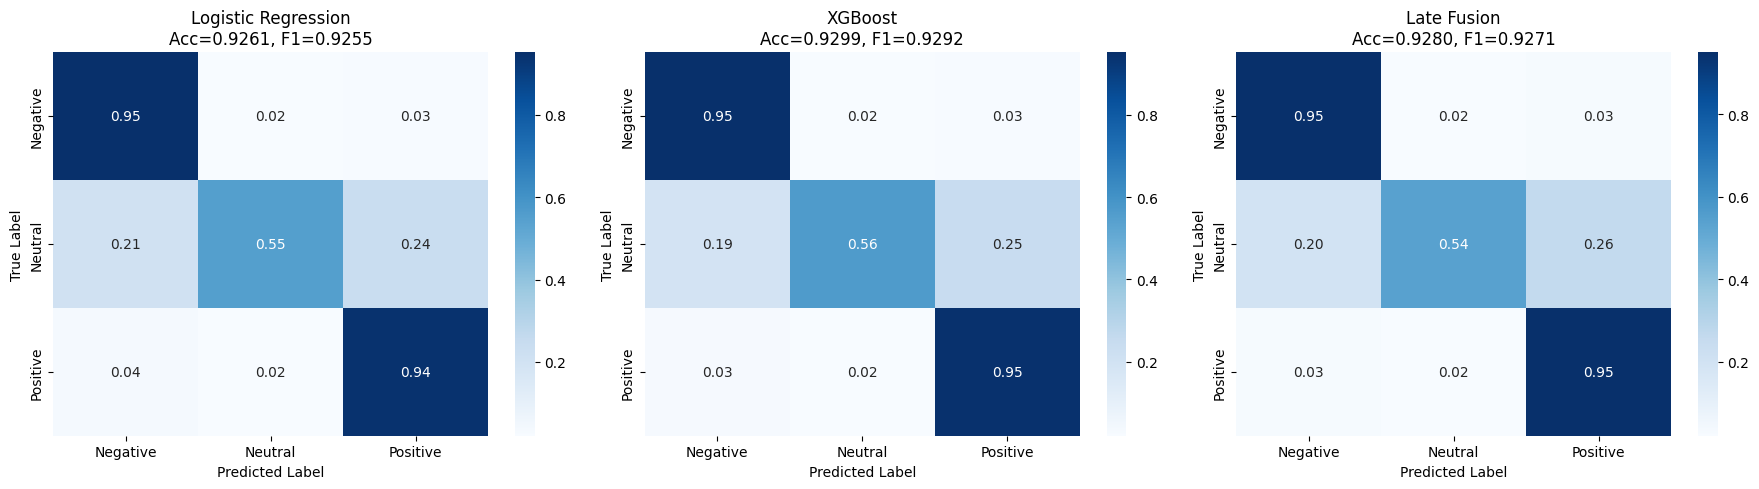

Confusion matrices saved to visualizations/


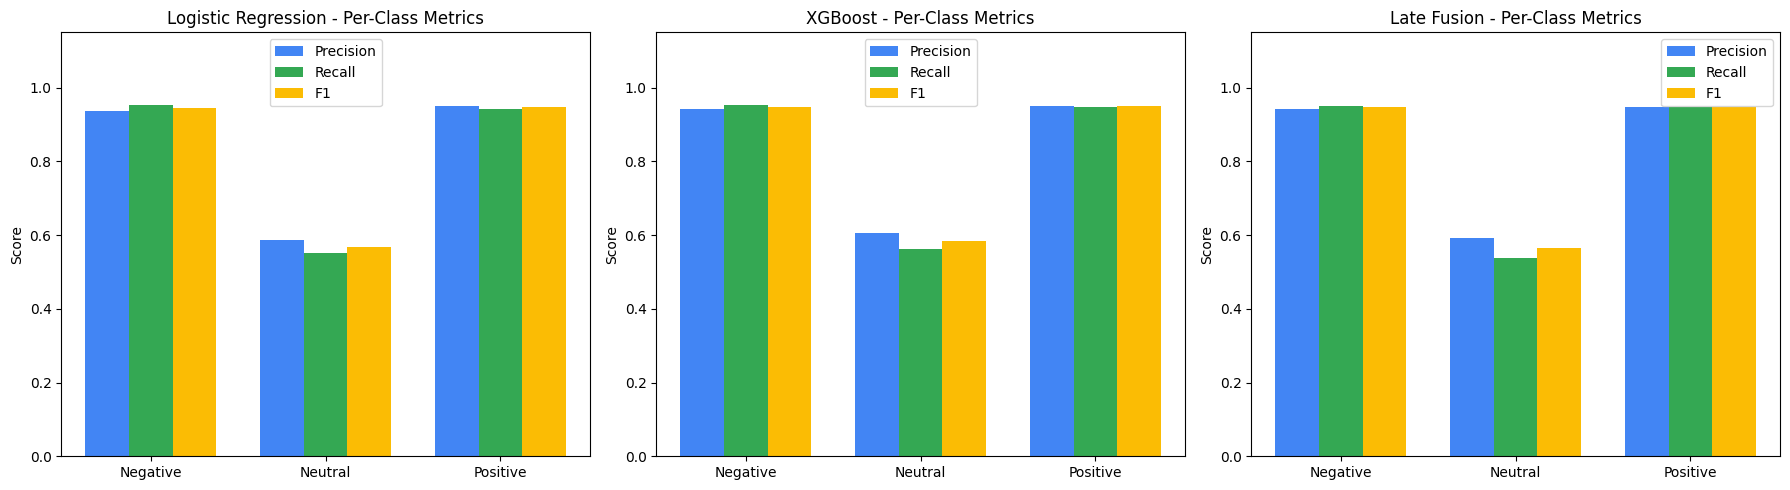

Per-class metrics saved to visualizations/


In [15]:
print('=' * 60)
print('EVALUATION - DETAILED CLASSIFICATION REPORTS')
print('=' * 60)

for model_name, result in results.items():
    print(f'\n--- {model_name} ---')
    print(classification_report(
        test_labels, result['preds'],
        target_names=list(config.LABEL_MAP.values())
    ))

# Confusion matrix visualizations
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for idx, (model_name, result) in enumerate(results.items()):
    cm = confusion_matrix(test_labels, result['preds'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=axes[idx],
                xticklabels=list(config.LABEL_MAP.values()),
                yticklabels=list(config.LABEL_MAP.values()),
                cmap='Blues')
    axes[idx].set_title(
        f'{model_name}\nAcc={result["accuracy"]:.4f}, F1={result["f1"]:.4f}'
    )
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(
    os.path.join(config.VISUALIZATIONS_DIR, 'confusion_matrix.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Confusion matrices saved to visualizations/')

# Per-class metrics bar chart
from sklearn.metrics import precision_recall_fscore_support
labels_order = list(config.LABEL_MAP.values())
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for idx, (model_name, result) in enumerate(results.items()):
    prec, rec, f1, _ = precision_recall_fscore_support(
        test_labels, result['preds'], labels=[0, 1, 2]
    )
    x = np.arange(len(labels_order))
    w = 0.25
    axes[idx].bar(x - w, prec, w, label='Precision', color='#4285F4')
    axes[idx].bar(x,     rec,  w, label='Recall',    color='#34A853')
    axes[idx].bar(x + w, f1,   w, label='F1',        color='#FBBC04')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(labels_order)
    axes[idx].set_ylim(0, 1.15)
    axes[idx].set_title(f'{model_name} - Per-Class Metrics')
    axes[idx].legend()
    axes[idx].set_ylabel('Score')
plt.tight_layout()
plt.savefig(
    os.path.join(config.VISUALIZATIONS_DIR, 'per_class_metrics.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Per-class metrics saved to visualizations/')


## 9. Model Comparison & Save Results


📊 MODEL COMPARISON
              Model  Accuracy  F1 (weighted)
            XGBoost  0.929880       0.929192
        Late Fusion  0.927985       0.927078
Logistic Regression  0.926090       0.925499


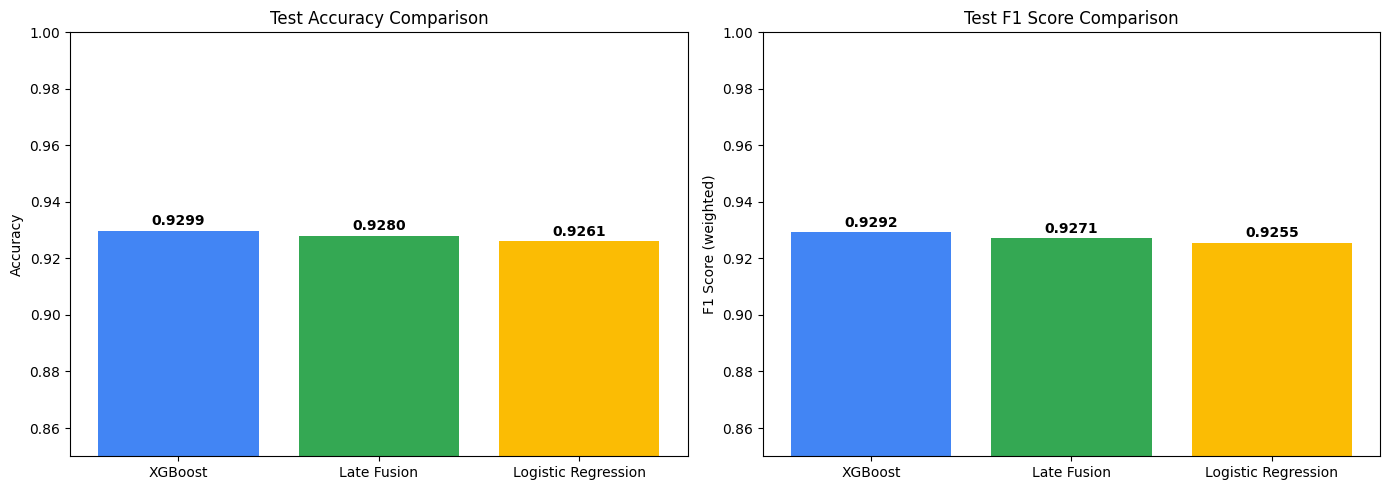

💾 SAVING MODELS & RESULTS
✅ Saved: models/lr_smote_model.pkl
✅ Saved: models/xgboost_smote_model.pkl
✅ Saved: models/late_fusion_model.pkl
✅ Saved: summaries/experiment_summary.json

📁 All results saved to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TF-IDF/improvements/20260305
   ├── models/
   ├── summaries/
   ├── visualizations/
   └── artifacts/

🏆 BEST MODEL: XGBoost
   Accuracy: 0.9299
   F1 (weighted): 0.9292
Saved: summaries/training_results.txt

All outputs saved to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TF-IDF/improvements/20260305


In [16]:
import pandas as pd
import json

comparison_data = []
for name, res in results.items():
    comparison_data.append({'Model': name, 'Accuracy': res['accuracy'], 'F1 (weighted)': res['f1']})
comparison_df = pd.DataFrame(comparison_data).sort_values('F1 (weighted)', ascending=False)

print('\n' + '='*60)
print('📊 MODEL COMPARISON')
print('='*60)
print(comparison_df.to_string(index=False))

# NEW: Save to summaries directory
comparison_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'model_comparison.csv'), index=False)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4285F4', '#34A853', '#FBBC04']
axes[0].bar(comparison_df['Model'], comparison_df['Accuracy'], color=colors[:len(comparison_df)])
axes[0].set_title('Test Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.85, 1.0)
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].bar(comparison_df['Model'], comparison_df['F1 (weighted)'], color=colors[:len(comparison_df)])
axes[1].set_title('Test F1 Score Comparison')
axes[1].set_ylabel('F1 Score (weighted)')
axes[1].set_ylim(0.85, 1.0)
for i, v in enumerate(comparison_df['F1 (weighted)']):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
# NEW: Save to visualizations directory
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'model_comparison_bar.png'), dpi=150)
plt.show()

# Save best model and summary
best_model_name = comparison_df.iloc[0]['Model']
best_result = results[best_model_name]

# NEW: Save models with proper naming
print('='*60)
print('💾 SAVING MODELS & RESULTS')
print('='*60)

if 'Logistic Regression' in results:
    with open(os.path.join(config.MODELS_DIR, 'lr_smote_model.pkl'), 'wb') as f:
        pickle.dump(results['Logistic Regression']['model'], f)
    print('✅ Saved: models/lr_smote_model.pkl')

if 'XGBoost' in results:
    with open(os.path.join(config.MODELS_DIR, 'xgboost_smote_model.pkl'), 'wb') as f:
        pickle.dump(results['XGBoost']['model'], f)
    print('✅ Saved: models/xgboost_smote_model.pkl')

if 'Late Fusion' in results:
    with open(os.path.join(config.MODELS_DIR, 'late_fusion_model.pkl'), 'wb') as f:
        pickle.dump(results['Late Fusion']['model'], f)
    print('✅ Saved: models/late_fusion_model.pkl')

# Save experiment summary
summary = {
    'Best Model': best_model_name,
    'Accuracy': float(best_result['accuracy']),
    'F1 (weighted)': float(best_result['f1']),
    'Improvements': [
        'SMOTE for class imbalance (Neutral: 458→3000)',
        'Reduced TF-IDF features (5000→3000)',
        'Stronger regularization (C: 1.0→0.1)',
        'Added trigrams (1,2)→(1,3)',
        'XGBoost classifier',
        'Late fusion approach'
    ]
}
with open(os.path.join(config.SUMMARIES_DIR, 'experiment_summary.json'), 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print('✅ Saved: summaries/experiment_summary.json')

print(f'\n📁 All results saved to: {config.RESULTS_DIR}')
print(f'   ├── models/')
print(f'   ├── summaries/')
print(f'   ├── visualizations/')
print(f'   └── artifacts/')
print(f'\n🏆 BEST MODEL: {best_model_name}')
print(f'   Accuracy: {best_result["accuracy"]:.4f}')
print(f'   F1 (weighted): {best_result["f1"]:.4f}')
# ----------------------------------------
# Save training_results.txt (REQUIRED)
# ----------------------------------------
from datetime import datetime

best_model_name = comparison_df.iloc[0]['Model']
best_result = results[best_model_name]

best_report = classification_report(
    test_labels, best_result['preds'],
    target_names=list(config.LABEL_MAP.values()),
    output_dict=True
)

lines = [
    '=' * 40,
    'TRAINING RESULTS - PhoBERT + TF-IDF Hybrid (Improved)',
    '=' * 40,
    f'Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
    'Model Type: PhoBERT_TF-IDF',
    'Experiment: improvements/20260305',
    '',
    '-' * 40,
    'HYPERPARAMETERS',
    '-' * 40,
    f'PhoBERT Model: {config.MODEL_NAME}',
    f'Max Length: {config.MAX_LENGTH}',
    f'Batch Size: {config.BATCH_SIZE}',
    f'TF-IDF Max Features: {config.TFIDF_MAX_FEATURES}',
    f'TF-IDF N-gram Range: {config.TFIDF_NGRAM_RANGE}',
    f'SMOTE Strategy: {config.SMOTE_SAMPLING_STRATEGY}',
    'LR C (regularization): 0.1',
    'XGBoost: n_estimators=200, max_depth=6, learning_rate=0.1',
    '',
    '-' * 40,
    f'TEST RESULTS (BEST MODEL: {best_model_name})',
    '-' * 40,
    f'Test Accuracy: {best_result["accuracy"]:.4f}',
    f'Test F1 (weighted): {best_result["f1"]:.4f}',
    '',
    'Per-Class Metrics (Best Model):',
    f'  Negative: P={best_report["Negative"]["precision"]:.4f}, R={best_report["Negative"]["recall"]:.4f}, F1={best_report["Negative"]["f1-score"]:.4f}',
    f'  Neutral:  P={best_report["Neutral"]["precision"]:.4f}, R={best_report["Neutral"]["recall"]:.4f}, F1={best_report["Neutral"]["f1-score"]:.4f}',
    f'  Positive: P={best_report["Positive"]["precision"]:.4f}, R={best_report["Positive"]["recall"]:.4f}, F1={best_report["Positive"]["f1-score"]:.4f}',
    '',
    'All Models Summary:',
]
for name, res in results.items():
    lines.append(f'  {name}: Acc={res["accuracy"]:.4f}, F1={res["f1"]:.4f}')

training_results_path = os.path.join(config.SUMMARIES_DIR, 'training_results.txt')
with open(training_results_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))
print('Saved: summaries/training_results.txt')
print(f'\nAll outputs saved to: {config.RESULTS_DIR}')
